# Thesis Experiment: RL-Based Gamma Controller (Weekly Rebalancing)
**Setup:** 7-Day Rebalancing Frequency for realistic portfolio management.

---

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded.")

Libraries loaded.


## Phase 1: Data Preparation

In [86]:
file_old = 'crypto_data_real.xlsx'
file_2024 = 'crypto_data_2024.xlsx'

def load_and_preprocess(f1, f2):
    r_old = pd.read_excel(f1, sheet_name='Returns', index_col=0)
    r_2024 = pd.read_excel(f2, sheet_name='Returns', index_col=0)
    r_old.index = pd.to_datetime(r_old.index)
    r_2024.index = pd.to_datetime(r_2024.index)
    assets = list(set(r_old.columns) & set(r_2024.columns))
    assets.sort()
    return r_old[assets], r_2024[assets], assets

ret_old, ret_2024, assets = load_and_preprocess(file_old, file_2024)
print(f"Data loaded. Assets: {len(assets)}")

Data loaded. Assets: 10


## Phase 2: Core Functions

In [87]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = np.mean(eigenvalues[eigenvalues < lambda_max])
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def get_centrality_weights(returns_window, gamma=1.0):
    corr_f = apply_rmt_filter(returns_window)
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    adj = np.maximum(0, 1 - dist_mat)
    G = nx.from_numpy_array(adj)
    try:
        centrality = nx.eigenvector_centrality(G, max_iter=2000)
        centrality_vec = np.array([centrality[i] for i in range(len(centrality))])
    except:
        centrality_vec = np.array(list(nx.degree_centrality(G).values()))
    eps = 1e-8
    adj_weights = (centrality_vec + eps) ** gamma
    return adj_weights / np.sum(adj_weights)

class PortfolioStrategy:
    def __init__(self, name): 
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()
    
class EquallyWeighted(PortfolioStrategy):
    def compute_weights(self, returns_window): return np.ones(returns_window.shape[1])/returns_window.shape[1]
class ClassicalMarkowitz(PortfolioStrategy):
    def compute_weights(self, returns_window):
        cov = returns_window.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)
class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, returns_window): return get_centrality_weights(returns_window, self.gamma)

## Phase 3: RL Agent

In [88]:
class GammaPortfolioEnv(gym.Env):
    def __init__(self, returns_data, window_size=120, reward_mode='sharpe'):
        super().__init__()
        self.data = returns_data
        self.window_size = window_size
        self.reward_mode = reward_mode
        self.current_step = window_size
        self.action_space = spaces.Box(low=0.1, high=10.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(4,), dtype=np.float32)
        
    def _get_obs(self):
        win = self.data.iloc[self.current_step - self.window_size : self.current_step]
        return np.array([win.mean().mean(), win.std().mean(), win.corr().values.mean(), np.std(get_centrality_weights(win))], dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        return self._get_obs(), {}
        
    def step(self, action):
        win = self.data.iloc[self.current_step - self.window_size : self.current_step]
        w = get_centrality_weights(win, float(action[0]))
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        
        if self.reward_mode == 'raw_return': reward = port_ret
        else: reward = port_ret / (win.values.std() + 1e-6)
            
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs(), reward, done, False, {}

class RLNetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, model_path):
        super().__init__(name)
        self.model = PPO.load(model_path)
    def compute_weights(self, returns_window):
        obs = np.array([returns_window.mean().mean(), returns_window.std().mean(), returns_window.corr().values.mean(), np.std(get_centrality_weights(returns_window))], dtype=np.float32)
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(action[0])
        return get_centrality_weights(returns_window, gamma=self.last_gamma)

## Phase 4: Backtest Engine (Fixed Frequency Rebalancing)

In [89]:
def run_backtest_with_frequency(strategy, data, window=120, rebalance_freq=7):
    rets = []
    dates = []
    weights_history = []
    gamma_history = []
    
    current_weights = None
    current_gamma = 1.0
    
    print(f"Processing {strategy.name} (Freq: {rebalance_freq} days)...")
    for i in range(window, len(data)):
        # REBALANCE ONLY EVERY 'rebalance_freq' DAYS
        if (i - window) % rebalance_freq == 0:
            window_df = data.iloc[i-window : i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma = getattr(strategy, 'last_gamma', 1.0)
        
        # DAILY RETURN CALCULATION
        r = np.dot(current_weights, data.iloc[i].values)
        rets.append(r)
        dates.append(data.index[i])
        weights_history.append(current_weights)
        gamma_history.append(current_gamma)
        
    return pd.Series(rets, index=dates), pd.DataFrame(weights_history, index=dates, columns=data.columns), pd.Series(gamma_history, index=dates)

def calculate_metrics(r):
    cr = (1+r).cumprod()
    sharpe = (np.mean(r)/np.std(r))*np.sqrt(252)
    mdd = ((cr/cr.expanding().max())-1).min()
    return {"Total Return": f"{cr.iloc[-1]-1:.2%}", "Sharpe": f"{sharpe:.2f}", "MDD": f"{mdd:.2%}"}

## Phase 5: Comparative Analysis (7-Day Rebalancing)

Training RL Models...
Processing EW ($1/N$) (Freq: 7 days)...
Processing Markowitz (MVP) (Freq: 7 days)...
Processing RL-Net (Sharpe) (Freq: 7 days)...
Processing RL-Net (Raw Return) (Freq: 7 days)...


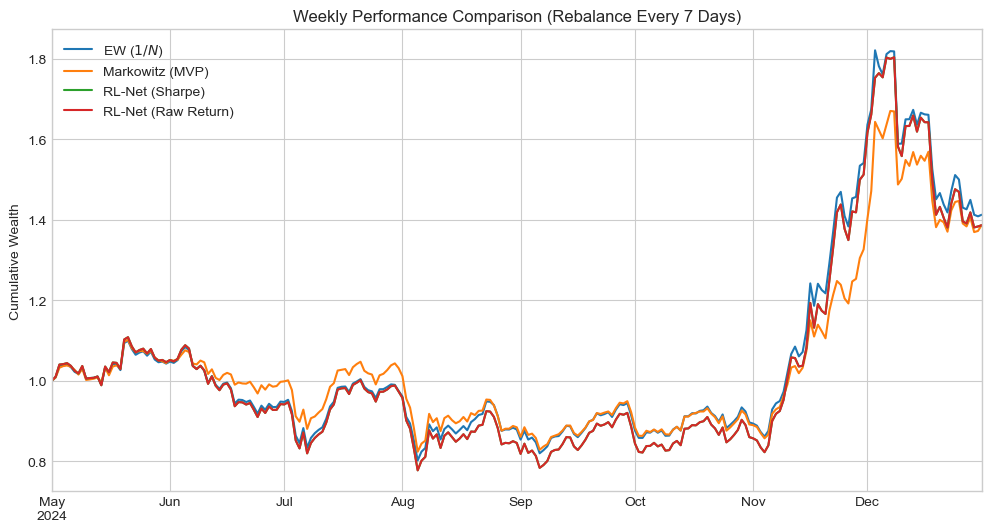


--- Final Performance Table (Weekly Rebalancing) ---
                    Total Return Sharpe      MDD
EW ($1/N$)                41.30%   1.06  -27.04%
Markowitz (MVP)           38.77%   1.06  -25.23%
RL-Net (Sharpe)           38.71%   0.98  -29.84%
RL-Net (Raw Return)       38.71%   0.98  -29.84%


In [90]:
SET_WINDOW = 120
SET_REBALANCE = 7  # EVERY 1 WEEK

train_data = ret_old.iloc[:int(len(ret_old)*0.8)]

print("Training RL Models...")
model_sharpe = PPO("MlpPolicy", GammaPortfolioEnv(train_data, window_size=SET_WINDOW, reward_mode='sharpe'), verbose=0).learn(10000)
model_sharpe.save("final_weekly_sharpe")
model_raw = PPO("MlpPolicy", GammaPortfolioEnv(train_data, window_size=SET_WINDOW, reward_mode='raw_return'), verbose=0).learn(10000)
model_raw.save("final_weekly_raw")

strategies = [
    EquallyWeighted("EW ($1/N$)"), 
    ClassicalMarkowitz("Markowitz (MVP)"), 
    RLNetworkMarkowitz("RL-Net (Sharpe)", "final_weekly_sharpe"),
    RLNetworkMarkowitz("RL-Net (Raw Return)", "final_weekly_raw")
]

results_map = {}
for s in strategies:
    res, _, _ = run_backtest_with_frequency(s, ret_2024, window=SET_WINDOW, rebalance_freq=SET_REBALANCE)
    results_map[s.name] = res

# 3. Plot
plt.figure(figsize=(12, 6))
for name, r in results_map.items(): (1+r).cumprod().plot(label=name)
plt.title(f"Weekly Performance Comparison (Rebalance Every {SET_REBALANCE} Days)")
plt.ylabel("Cumulative Wealth"); plt.legend(); plt.grid(True); plt.show()

print("\n--- Final Performance Table (Weekly Rebalancing) ---")
print(pd.DataFrame({n: calculate_metrics(r) for n, r in results_map.items()}).T)